# Demand Forecasting and Revenue Optimization for an E-Commerce Marketplace
### BDM Capstone Project — Analysis Notebook (Google Colab)
**Name:** Nishika Chapra &nbsp;|&nbsp; **Roll Number:** 23F3000862 &nbsp;|&nbsp; **Email:** 23f3000862@ds.study.iitm.ac.in

**Dataset:** [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle)

This notebook reproduces **every figure and table referenced in the Final Report and the Viva presentation**,
in the same order as the report: data loading → cleaning/preprocessing → descriptive statistics →
EDA (Figures 1–6) → time-series trend (Figure 7) → RFM clustering (Figures 8–10) → regression (Figures 11–12)
→ summary of findings. The colour palette (navy / red / light-blue / orange) matches the Final Report and the
presentation deck exactly, so a reviewer sees the same charts in all three places.

**Run this in Google Colab:** Runtime → Run all. The first cell mounts your Google Drive and expects
8 of the 9 files in the Kaggle Olist dataset inside a folder there — everything except `geolocation`,
which isn't needed for this analysis. See Cell 1 for the exact path.


## 0. Setup, Imports, and Data Location

**Before running:** in Google Drive, create a folder (e.g. `MyDrive/BDM_Capstone/data/`) and upload the 9 CSVs
downloaded from the Kaggle link above, using their original Kaggle filenames. Update `DATA_DIR` below if you
used a different folder name.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Mount Google Drive (skip this cell if running locally instead of Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/BDM_Capstone/data/'   # <-- update to match your Drive folder
except ImportError:
    DATA_DIR = 'data/'   # local fallback if not running in Colab

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# Consistent colour palette used across every chart in the Final Report and the presentation deck -
# keep this identical everywhere so the notebook, report, and slides visually match.
BLUE, LBLUE, RED, ORANGE, TEAL, GREY = '#1B3A6B', '#5B8FC7', '#C0392B', '#D98F3C', '#3C7A89', '#AAAAAA'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10


## 1. Load the Data

Eight interrelated CSV files covering the full order lifecycle: orders, order items, payments, reviews,
customers, sellers, products, and the product-category translation table. (`geolocation` is part of the
Kaggle dataset but isn't required for any figure in this analysis, so it's not loaded here.)

In [2]:
orders    = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date'])
items     = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv', parse_dates=['shipping_limit_date'])
payments  = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
sellers   = pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv')
products  = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
cat_trans = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')

print(f"orders:    {orders.shape}")
print(f"items:     {items.shape}")
print(f"payments:  {payments.shape}")
print(f"reviews:   {reviews.shape}")
print(f"customers: {customers.shape}")
print(f"sellers:   {sellers.shape}")
print(f"products:  {products.shape}")


orders:    (99441, 8)
items:     (112650, 7)
payments:  (103886, 5)
reviews:   (99224, 7)
customers: (99441, 5)
sellers:   (3095, 4)
products:  (32951, 9)


## 2. Data Cleaning and Preprocessing
*(Report Section 4.1)*

The raw dataset was examined for missing values, duplicates, and data-type inconsistencies before any
analysis began. Three timestamp columns in the `orders` table have structurally missing values —
they correspond to orders that were never delivered, so they are **excluded from delivery-timing
analysis rather than imputed**, since imputing a delivery date for an order that was never delivered
would fabricate data.

In [3]:
missing = orders[['order_approved_at', 'order_delivered_carrier_date',
                   'order_delivered_customer_date']].isna().sum()
missing_pct = (missing / len(orders) * 100).round(2)
print(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}))

print(f"\nDuplicate order_id entries: {orders['order_id'].duplicated().sum()}")
print(f"\nOrder status breakdown:")
print(orders['order_status'].value_counts())


                               missing_count  missing_pct
order_approved_at                        160         0.16
order_delivered_carrier_date            1783         1.79
order_delivered_customer_date           2965         2.98

Duplicate order_id entries: 0

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [4]:
# The payments table has more rows than there are orders, because a single order can be paid
# in multiple instalments/methods. Aggregate to one row per order before using it anywhere else.
print(f"payments rows: {len(payments):,}  |  unique orders in payments: {payments['order_id'].nunique():,}")

pay_order = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max')
).reset_index()


payments rows: 103,886  |  unique orders in payments: 99,440


In [5]:
# Only 'delivered' orders have a real delivery date, so delay_days is only meaningful for them.
# delay_days is defined at whole-calendar-day granularity (report Equation 2):
#   Delivery Delay (days) = Actual Delivery Date - Estimated Delivery Date
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delay_days'] = (
    delivered['order_delivered_customer_date'].dt.normalize()
    - delivered['order_estimated_delivery_date'].dt.normalize()
).dt.days

print(f"Delivered orders: {len(delivered):,} ({len(delivered)/len(orders)*100:.1f}% of all orders)")
print(delivered['delay_days'].describe())


Delivered orders: 96,478 (97.0% of all orders)
count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64


In [6]:
# Order-level item aggregates: total price, total freight, and item count per order
item_order = items.groupby('order_id').agg(
    price=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    item_count=('order_item_id', 'count')
).reset_index()

item_order.describe()


,price,freight_value,item_count
count,98666.000000,98666.000000,98666.000000
mean,137.754076,22.823562,1.141731
std,210.645145,21.650909,0.538452
min,0.850000,0.000000,1.000000
25%,45.900000,13.850000,1.000000
50%,86.900000,17.170000,1.000000
75%,149.900000,24.040000,1.000000
max,13440.000000,1794.960000,21.000000


### Raw vs. Cleaned Data — Exported for Live Demonstration

If asked in the viva to *show* the raw data and the cleaned data (not just describe the process),
run the two cells below. They save both versions to disk so they can be opened directly:

- **Raw**: `data/raw_orders_snapshot.csv` — the `orders` table exactly as loaded from the Kaggle CSV,
  before any filtering, merging, or cleaning. Still has the structurally-missing timestamps and
  includes cancelled/undelivered orders.
- **Cleaned**: `data/cleaned_master_dataset.csv` — the analysis-ready, order-level table used
  throughout this notebook: filtered to `delivered` orders only, instalments aggregated to one
  payment total per order, item/freight/price aggregated per order, customer and seller state
  attached, review score attached, and every row guaranteed to have no missing values in the
  fields the analysis depends on (`review_score` is the one exception left in — a missing review
  is a real customer behaviour, not a data defect, so it's kept rather than dropped).

In [7]:
# --- RAW data: exactly as loaded, no cleaning applied yet ---
raw_orders_snapshot = orders.copy()

print(f"RAW orders table: {raw_orders_snapshot.shape[0]:,} rows x {raw_orders_snapshot.shape[1]} columns")
print(f"\nMissing values (raw):")
print(raw_orders_snapshot.isna().sum()[raw_orders_snapshot.isna().sum() > 0])
print(f"\nOrder statuses present (raw includes cancelled/unavailable/etc, not just delivered):")
print(raw_orders_snapshot['order_status'].value_counts())

raw_orders_snapshot.to_csv(DATA_DIR + 'raw_orders_snapshot.csv', index=False)
print(f"\nSaved -> {DATA_DIR}raw_orders_snapshot.csv")
raw_orders_snapshot.head()


RAW orders table: 99,441 rows x 8 columns

Missing values (raw):
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Order statuses present (raw includes cancelled/unavailable/etc, not just delivered):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64



Saved -> data/raw_orders_snapshot.csv


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [8]:
# --- CLEANED data: analysis-ready, one row per delivered order, no missing values in used fields ---
seller_state_lookup = items.merge(sellers[['seller_id', 'seller_state']], on='seller_id') \
                            .groupby('order_id')['seller_state'].first().reset_index()

cleaned_master = delivered.merge(item_order, on='order_id', how='inner')
cleaned_master = cleaned_master.merge(pay_order, on='order_id', how='left')
cleaned_master = cleaned_master.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='left')
cleaned_master = cleaned_master.merge(seller_state_lookup, on='order_id', how='left')
cleaned_master = cleaned_master.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# A handful of orders are flagged order_status='delivered' but are still missing an actual
# delivery timestamp (a known inconsistency in the raw Olist data) -- delay_days is NaN for
# these, so they're dropped here along with any row missing a field the analysis depends on.
# review_score is NOT dropped on -- a missing review is a legitimate real-world case (not every
# customer leaves one), not a data-quality defect, so those rows are kept with review_score = NaN.
required_fields = ['delay_days', 'payment_value', 'customer_state', 'seller_state']
cleaned_master = cleaned_master.dropna(subset=required_fields)

print(f"CLEANED master dataset: {cleaned_master.shape[0]:,} rows x {cleaned_master.shape[1]} columns")
print(f"(down from {raw_orders_snapshot.shape[0]:,} raw rows -- the difference is non-delivered orders "
      f"and rows missing a required field, both excluded deliberately, not imputed)")
print(f"\nMissing values remaining in cleaned data (required fields should show 0; review_score is "
      f"expected to have some -- not every order gets a review):")
remaining_na = cleaned_master.isna().sum()
print(remaining_na[remaining_na > 0] if remaining_na.sum() > 0 else "None")

cleaned_master.to_csv(DATA_DIR + 'cleaned_master_dataset.csv', index=False)
print(f"\nSaved -> {DATA_DIR}cleaned_master_dataset.csv")
cleaned_master.head()


CLEANED master dataset: 96,998 rows x 18 columns
(down from 99,441 raw rows -- the difference is non-delivered orders and rows missing a required field, both excluded deliberately, not imputed)

Missing values remaining in cleaned data (required fields should show 0; review_score is expected to have some -- not every order gets a review):
order_approved_at                14
order_delivered_carrier_date      1
review_score                    646
dtype: int64



Saved -> data/cleaned_master_dataset.csv


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delay_days,price,freight_value,item_count,payment_value,payment_installments,customer_unique_id,customer_state,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,29.99,8.72,1,38.71,1.0,7c396fd4830fd04220f754e42b4e5bff,SP,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,118.70,22.76,1,141.46,1.0,af07308b275d755c9edb36a90c618231,BA,SP,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,159.90,19.22,1,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8,GO,SP,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,45.00,27.20,1,72.20,1.0,7c142cf63193a1473d2e66489a9ae977,RN,MG,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,19.90,8.72,1,28.62,1.0,72632f0f9dd73dfee390c9b22eb56dd6,SP,SP,5.0


## 3. Metadata and Descriptive Statistics
*(Report Section 3 — Table 1 and Table 2)*

Table 1 in the report is a hand-written variable dictionary; the cell below reproduces the numbers that
back it (ranges, categorical shares) directly from the data so every figure quoted in the report table is
traceable to code.

In [9]:
summary_vars = pd.DataFrame({
    'payment_value': pay_order['payment_value'],
    'price (order)': item_order['price'],
    'freight_value': item_order['freight_value'],
    'item_count': item_order['item_count'],
})
print("--- Value ranges (Table 1: Range / Values column) ---")
for col in summary_vars:
    s = summary_vars[col].dropna()
    print(f"{col:18s}  min={s.min():>10,.2f}   max={s.max():>10,.2f}")

print("\n--- order_status shares ---")
print((orders['order_status'].value_counts(normalize=True) * 100).round(1))

print("\n--- payment_type shares ---")
print((payments['payment_type'].value_counts(normalize=True) * 100).round(1))

print("\n--- customer_state top 3 ---")
print((customers['customer_state'].value_counts(normalize=True) * 100).round(1).head(3))

print("\n--- seller_state top 3 ---")
print((sellers['seller_state'].value_counts(normalize=True) * 100).round(1).head(3))
print(f"Unique customer states: {customers['customer_state'].nunique()}  |  "
      f"Unique seller states: {sellers['seller_state'].nunique()}")


--- Value ranges (Table 1: Range / Values column) ---
payment_value       min=      0.00   max= 13,664.08
price (order)       min=      0.85   max= 13,440.00
freight_value       min=      0.00   max=  1,794.96
item_count          min=      1.00   max=     21.00

--- order_status shares ---
order_status
delivered      97.0
shipped         1.1
canceled        0.6
unavailable     0.6
invoiced        0.3
processing      0.3
created         0.0
approved        0.0
Name: proportion, dtype: float64

--- payment_type shares ---
payment_type
credit_card    73.9
boleto         19.0
voucher         5.6
debit_card      1.5
not_defined     0.0
Name: proportion, dtype: float64

--- customer_state top 3 ---
customer_state
SP    42.0
RJ    12.9
MG    11.7
Name: proportion, dtype: float64

--- seller_state top 3 ---
seller_state
SP    59.7
PR    11.3
MG     7.9
Name: proportion, dtype: float64
Unique customer states: 27  |  Unique seller states: 23


In [10]:
# Table 2: Descriptive Statistics for Key Numerical Variables
review_scores = reviews['review_score']

table2 = pd.DataFrame({
    'N':      [pay_order['payment_value'].count(), item_order['price'].count(), item_order['freight_value'].count(),
               review_scores.count(), delivered['delay_days'].count(), item_order['item_count'].count(),
               payments['payment_installments'].count()],
    'Mean':   [pay_order['payment_value'].mean(), item_order['price'].mean(), item_order['freight_value'].mean(),
               review_scores.mean(), delivered['delay_days'].mean(), item_order['item_count'].mean(),
               payments['payment_installments'].mean()],
    'Median': [pay_order['payment_value'].median(), item_order['price'].median(), item_order['freight_value'].median(),
               review_scores.median(), delivered['delay_days'].median(), item_order['item_count'].median(),
               payments['payment_installments'].median()],
    'Std Dev':[pay_order['payment_value'].std(), item_order['price'].std(), item_order['freight_value'].std(),
               review_scores.std(), delivered['delay_days'].std(), item_order['item_count'].std(),
               payments['payment_installments'].std()],
}, index=['payment_value', 'price (order level)', 'freight_value', 'review_score',
          'delay_days', 'item_count', 'payment_installments']).round(2)

table2


,N,Mean,Median,Std Dev
payment_value,99440,160.99,105.29,221.95
price (order level),98666,137.75,86.90,210.65
freight_value,98666,22.82,17.17,21.65
review_score,99224,4.09,5.00,1.35
delay_days,96470,-11.88,-12.00,10.18
item_count,98666,1.14,1.00,0.54
payment_installments,103886,2.85,1.00,2.69


In [11]:
# Equation 1: Late Delivery Rate = (Orders Delivered After Estimated Date / Total Delivered Orders) x 100
d = delivered.dropna(subset=['delay_days'])
n_late = (d['delay_days'] > 0).sum()
n_total = len(d)
late_rate = n_late / n_total * 100
avg_late_overrun = d.loc[d['delay_days'] > 0, 'delay_days'].mean()
avg_early = -d.loc[d['delay_days'] <= 0, 'delay_days'].mean()

print(f"Late delivery rate: ({n_late:,} / {n_total:,}) x 100 = {late_rate:.1f}%")
print(f"Average overrun among late orders: {avg_late_overrun:.2f} days")
print(f"Average early arrival among on-time/early orders: {avg_early:.2f} days")


Late delivery rate: (6,534 / 96,470) x 100 = 6.8%
Average overrun among late orders: 10.62 days
Average early arrival among on-time/early orders: 13.51 days


## 4. Exploratory Data Analysis — Figures 1–4
*(Report Section 5.1)*

### Figure 1 — Monthly Order Volume and Revenue

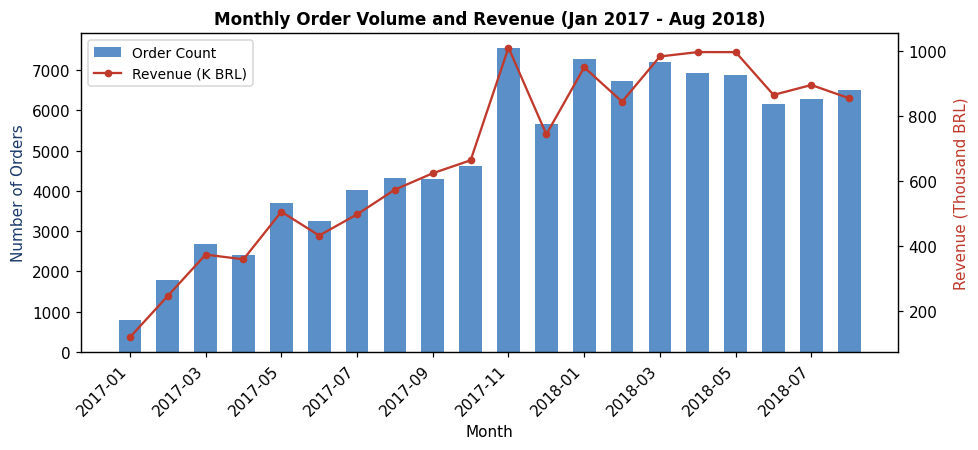

In [12]:
o = orders.copy()
o['month'] = o['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = o.groupby('month').size()

rev = item_order.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id')
rev['month'] = rev['order_purchase_timestamp'].dt.to_period('M')
monthly_rev = rev.groupby('month')['price'].sum() / 1000  # thousand BRL

# Restrict to full calendar months only (Jan-2017 to Aug-2018); the first and last
# months in the raw data are partial and would distort the trend.
full_months = monthly_orders[(monthly_orders.index >= '2017-01') & (monthly_orders.index <= '2018-08')]
full_rev = monthly_rev.reindex(full_months.index)

fig, ax1 = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(full_months))
ax1.bar(x, full_months.values, color=LBLUE, label='Order Count', width=0.6)
ax1.set_ylabel('Number of Orders', color=BLUE)
ax1.set_xticks(x[::2]); ax1.set_xticklabels([str(p) for p in full_months.index[::2]], rotation=45, ha='right')
ax1.set_xlabel('Month')
ax2 = ax1.twinx()
ax2.plot(x, full_rev.values, color=RED, marker='o', markersize=4, label='Revenue (K BRL)')
ax2.set_ylabel('Revenue (Thousand BRL)', color=RED)
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc='upper left', fontsize=9)
ax1.set_title('Monthly Order Volume and Revenue (Jan 2017 - Aug 2018)', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig1.png', dpi=170); plt.show()


### Figure 2 — Order Distribution by Day of Week

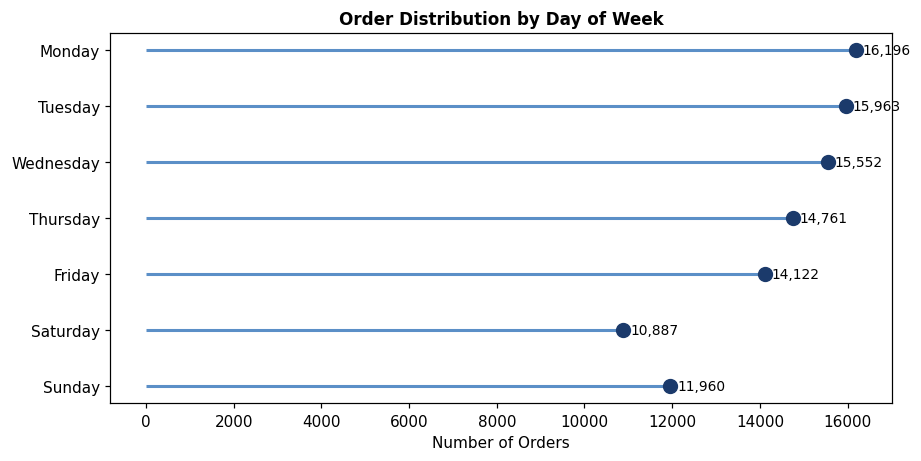

Monday leads at 16,196 orders, 35% higher than Sunday.


In [13]:
dow_map = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}
orders['dow'] = orders['order_purchase_timestamp'].dt.dayofweek.map(dow_map)
dow_counts = orders['dow'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

fig, ax = plt.subplots(figsize=(8.5, 4.3))
y_pos = np.arange(len(dow_counts))
ax.hlines(y_pos, 0, dow_counts.values, color=LBLUE, linewidth=2)
ax.plot(dow_counts.values, y_pos, 'o', color=BLUE, markersize=9)
for i, v in enumerate(dow_counts.values):
    ax.text(v + 150, i, f'{v:,}', va='center', fontsize=9)
ax.set_yticks(y_pos); ax.set_yticklabels(dow_counts.index)
ax.set_xlabel('Number of Orders')
ax.set_title('Order Distribution by Day of Week', fontsize=11, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig('fig2.png', dpi=170); plt.show()

print(f"Monday leads at {dow_counts['Monday']:,} orders, "
      f"{(dow_counts['Monday']/dow_counts['Sunday']-1)*100:.0f}% higher than Sunday.")


### Figure 3 — Top 10 Product Categories by Revenue

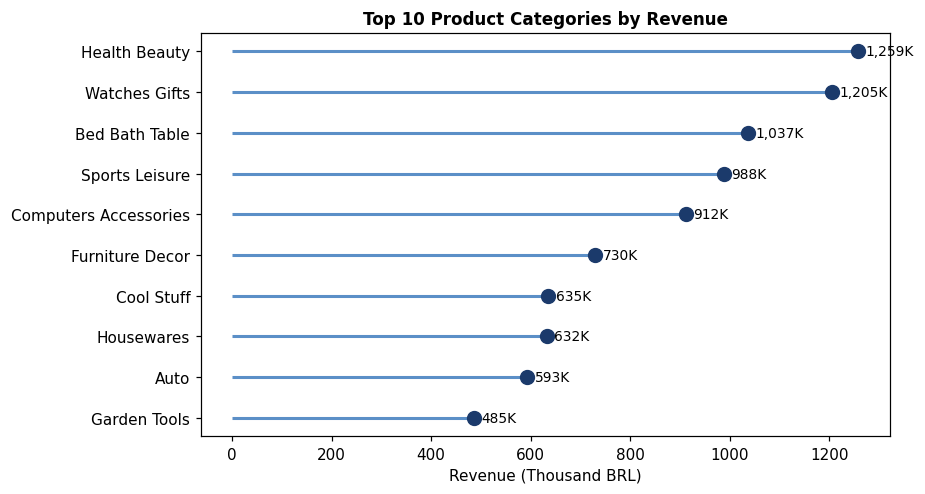

Top category: health_beauty  (BRL 1,259K)
Top-10 categories account for 63% of total platform revenue.


In [14]:
items_full = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_full = items_full.merge(cat_trans, on='product_category_name', how='left')

cat_rev = items_full.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)
top10 = cat_rev.head(10) / 1000  # thousand BRL

fig, ax = plt.subplots(figsize=(8.5, 4.6))
y_pos = np.arange(len(top10))
ax.hlines(y_pos, 0, top10.values, color=LBLUE, linewidth=2)
ax.plot(top10.values, y_pos, 'o', color=BLUE, markersize=9)
for i, v in enumerate(top10.values):
    ax.text(v + 15, i, f'{v:,.0f}K', va='center', fontsize=9)
ax.set_yticks(y_pos); ax.set_yticklabels([c.replace('_', ' ').title() for c in top10.index])
ax.set_xlabel('Revenue (Thousand BRL)')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=11, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig('fig3.png', dpi=170); plt.show()

top10_share = cat_rev.head(10).sum() / cat_rev.sum() * 100
print(f"Top category: {top10.index[0]}  (BRL {top10.values[0]:,.0f}K)")
print(f"Top-10 categories account for {top10_share:.0f}% of total platform revenue.")


### Figure 4 — Distribution of Payment Methods

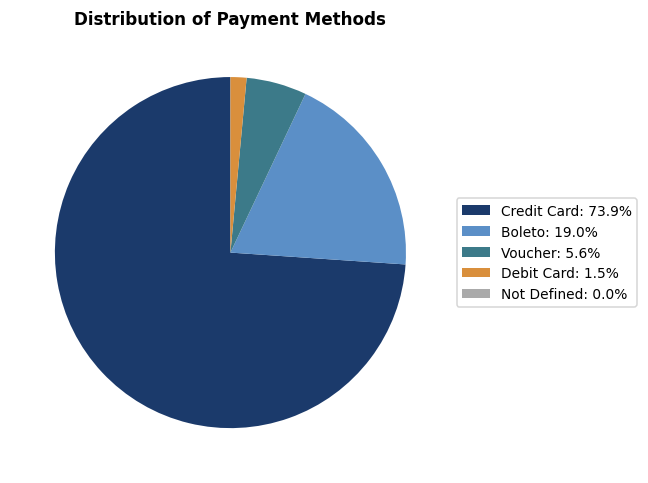

In [15]:
pt = payments['payment_type'].value_counts(normalize=True) * 100
labels = [l.replace('_', ' ').title() for l in pt.index]
colors = [BLUE, LBLUE, TEAL, ORANGE, GREY][:len(pt)]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
wedges, _ = ax.pie(pt.values, colors=colors, startangle=90)
ax.legend(wedges, [f'{l}: {v:.1f}%' for l, v in zip(labels, pt.values)],
          loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.set_title('Distribution of Payment Methods', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig4.png', dpi=170); plt.show()


### Figure 5 — Average Review Score by Delivery Timing Category

`delay_days` is bucketed into six ordered categories, then joined against `review_score` to test
whether delivery timing drives customer satisfaction.

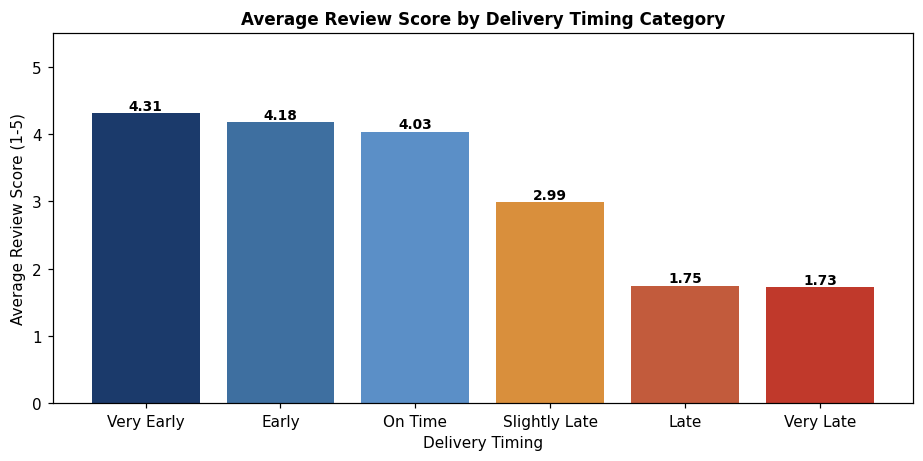

timing_cat
Very Early       4.31
Early            4.18
On Time          4.03
Slightly Late    2.99
Late             1.75
Very Late        1.73
Name: review_score, dtype: float64

On-time -> Slightly Late drop: 1.05 points


In [16]:
d = delivered.dropna(subset=['delay_days']).merge(
    reviews[['order_id', 'review_score']], on='order_id', how='inner')

def bucket(x):
    if x <= -7:  return 'Very Early'
    if x <= -1:  return 'Early'
    if x <= 0:   return 'On Time'
    if x <= 5:   return 'Slightly Late'
    if x <= 15:  return 'Late'
    return 'Very Late'

d['timing_cat'] = d['delay_days'].apply(bucket)
order_cats = ['Very Early','Early','On Time','Slightly Late','Late','Very Late']
timing_scores = d.groupby('timing_cat')['review_score'].mean().reindex(order_cats)
timing_n = d.groupby('timing_cat').size().reindex(order_cats)

colors5 = [BLUE, '#3E6FA0', '#5B8FC7', ORANGE, '#C25B3C', RED]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(order_cats, timing_scores.values, color=colors5)
for b, v in zip(bars, timing_scores.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Review Score (1-5)'); ax.set_xlabel('Delivery Timing'); ax.set_ylim(0, 5.5)
ax.set_title('Average Review Score by Delivery Timing Category', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig5.png', dpi=170); plt.show()

print(timing_scores.round(2))
print(f"\nOn-time -> Slightly Late drop: "
      f"{timing_scores['On Time'] - timing_scores['Slightly Late']:.2f} points")


### Figure 6 — Distribution of Delivery Delay

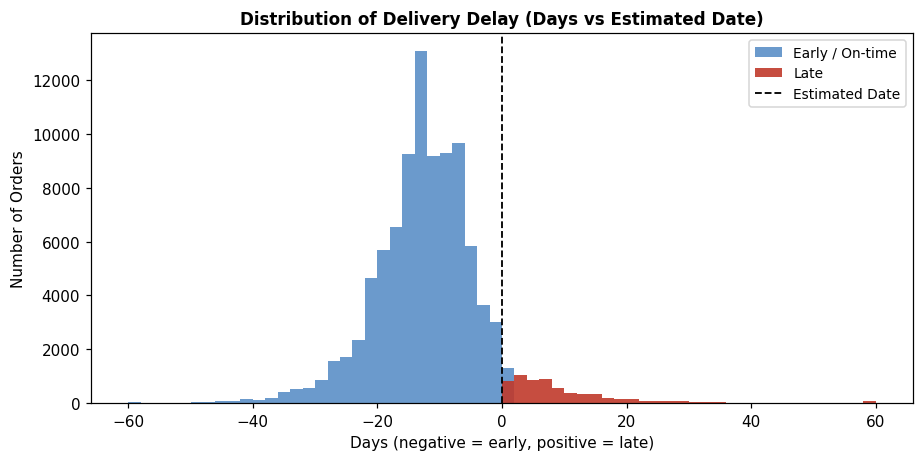

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 4.3))
early = d.loc[d['delay_days'] <= 0, 'delay_days']
late  = d.loc[d['delay_days'] > 0, 'delay_days']
bins = np.linspace(-60, 60, 61)
ax.hist(early.clip(-60, 60), bins=bins, color=LBLUE, label='Early / On-time', alpha=0.9)
ax.hist(late.clip(-60, 60), bins=bins, color=RED, label='Late', alpha=0.9)
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Estimated Date')
ax.set_xlabel('Days (negative = early, positive = late)'); ax.set_ylabel('Number of Orders')
ax.set_title('Distribution of Delivery Delay (Days vs Estimated Date)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('fig6.png', dpi=170); plt.show()


## 5. Time-Series Trend — Figure 7
*(Report Section 5.2, Method 2 — Equation 3: linear trend model)*

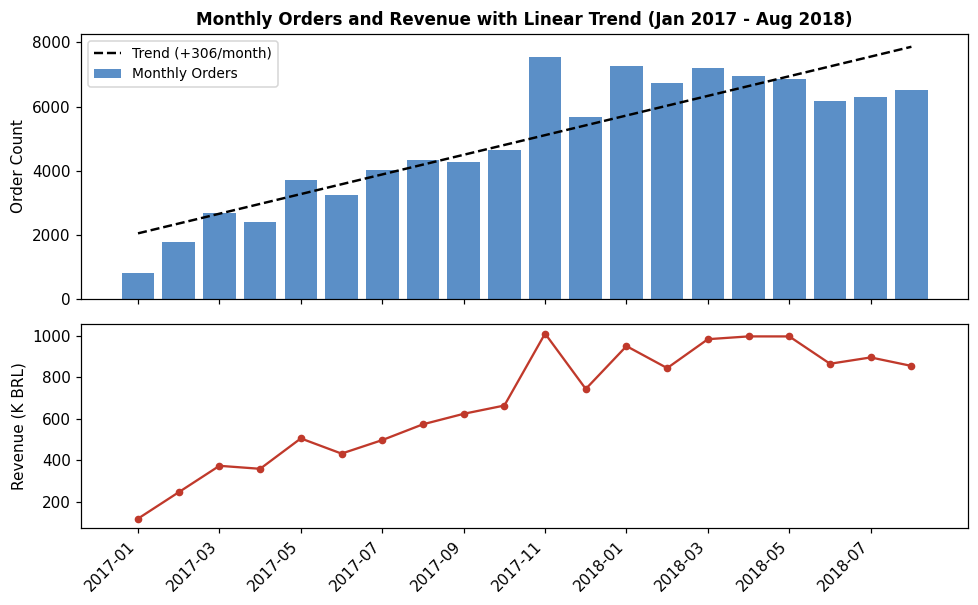

Linear trend slope: +306.5 orders/month


In [18]:
X = np.arange(len(full_months)).reshape(-1, 1)
y = full_months.values
lr_trend = LinearRegression().fit(X, y)
trend = lr_trend.predict(X)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.6), sharex=True, gridspec_kw={'height_ratios': [1.3, 1]})
x = np.arange(len(full_months))
ax1.bar(x, full_months.values, color=LBLUE, label='Monthly Orders')
ax1.plot(x, trend, color='black', linestyle='--', linewidth=1.6, label=f'Trend (+{lr_trend.coef_[0]:.0f}/month)')
ax1.set_ylabel('Order Count'); ax1.legend(fontsize=9)
ax1.set_title('Monthly Orders and Revenue with Linear Trend (Jan 2017 - Aug 2018)', fontsize=11, fontweight='bold')
ax2.plot(x, full_rev.values, color=RED, marker='o', markersize=4)
ax2.set_ylabel('Revenue (K BRL)')
ax2.set_xticks(x[::2]); ax2.set_xticklabels([str(p) for p in full_months.index[::2]], rotation=45, ha='right')
plt.tight_layout(); plt.savefig('fig7.png', dpi=170); plt.show()

print(f"Linear trend slope: +{lr_trend.coef_[0]:.1f} orders/month")


## 6. RFM Customer Segmentation — Figures 8–10
*(Report Section 5.3, Method 3 — Equations 4 & 5: z-score standardisation and WCSS)*

Recency, Frequency, and Monetary features are engineered per unique customer (`customer_unique_id`,
not `customer_id`, since each order gets its own `customer_id` in this dataset), z-score standardised,
then clustered with K-Means.

In [19]:
d_rfm = delivered.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
d_rfm = d_rfm.merge(pay_order[['order_id', 'payment_value']], on='order_id', how='left')

snapshot = d_rfm['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm = d_rfm.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda s: (snapshot - s.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index().dropna()

print(f"RFM table: {len(rfm):,} unique customers")
rfm[['recency', 'frequency', 'monetary']].describe().round(2)


RFM table: 93,358 unique customers


,recency,frequency,monetary
count,93358.00,93358.00,93358.00
mean,237.94,1.03,165.20
std,152.59,0.21,226.31
min,1.00,1.00,0.00
25%,114.00,1.00,63.05
50%,219.00,1.00,107.78
75%,346.00,1.00,182.56
max,714.00,15.00,13664.08


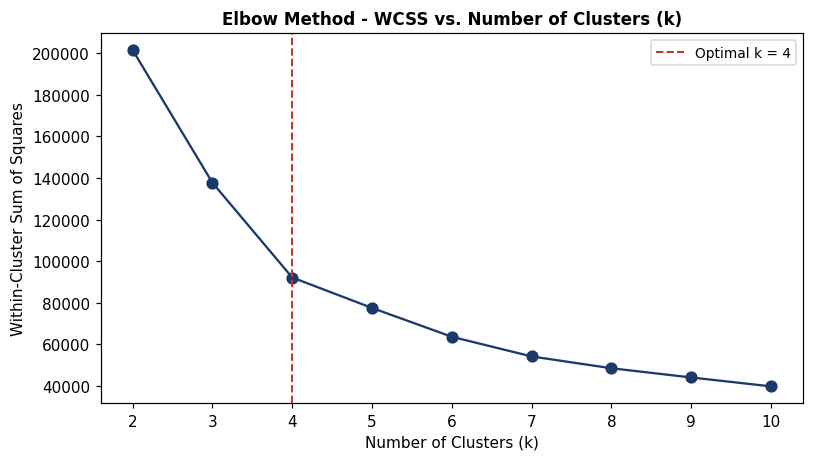

In [20]:
scaler = StandardScaler()
X_rfm = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

# Elbow method: fit k=2..10, plot WCSS to justify k=4
wcss = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_rfm)
    wcss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.plot(range(2, 11), wcss, marker='o', color=BLUE, markersize=7)
ax.axvline(4, color=RED, linestyle='--', linewidth=1.3, label='Optimal k = 4')
ax.set_xlabel('Number of Clusters (k)'); ax.set_ylabel('Within-Cluster Sum of Squares')
ax.set_title('Elbow Method - WCSS vs. Number of Clusters (k)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('fig8.png', dpi=170); plt.show()


In [21]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_rfm)
rfm['cluster'] = km4.labels_

prof = rfm.groupby('cluster').agg(n=('customer_unique_id', 'count'), recency=('recency', 'mean'),
                                   frequency=('frequency', 'mean'), monetary=('monetary', 'mean')).round(2)

# Business-label assignment by profile: highest monetary -> High-Value Champions,
# highest frequency among the rest -> Loyal, lowest recency of what's left -> New/Recent,
# the remainder -> Dormant.
hv = prof['monetary'].idxmax()
loyal = prof.drop(hv)['frequency'].idxmax()
remaining = prof.drop([hv, loyal])
newrecent = remaining['recency'].idxmin()
dormant = remaining.drop(newrecent).index[0]
label_map = {hv: 'High-Value Champions', loyal: 'Loyal Customers',
             newrecent: 'New / Recent Customers', dormant: 'Dormant Customers'}
rfm['label'] = rfm['cluster'].map(label_map)

order_lbls = ['High-Value Champions', 'Loyal Customers', 'New / Recent Customers', 'Dormant Customers']
prof_lbl = rfm.groupby('label').agg(n=('customer_unique_id', 'count'), recency=('recency', 'mean'),
                                     frequency=('frequency', 'mean'), monetary=('monetary', 'mean')
                                     ).round(2).loc[order_lbls]
prof_lbl


,n,recency,frequency,monetary
label,,,,
High-Value Champions,2418,239.40,1.01,1160.91
Loyal Customers,2772,220.44,2.11,289.68
New / Recent Customers,50642,128.07,1.00,134.36
Dormant Customers,37526,387.41,1.00,133.46


### Figure 9 — RFM Clusters (Recency vs. Monetary Scatter)

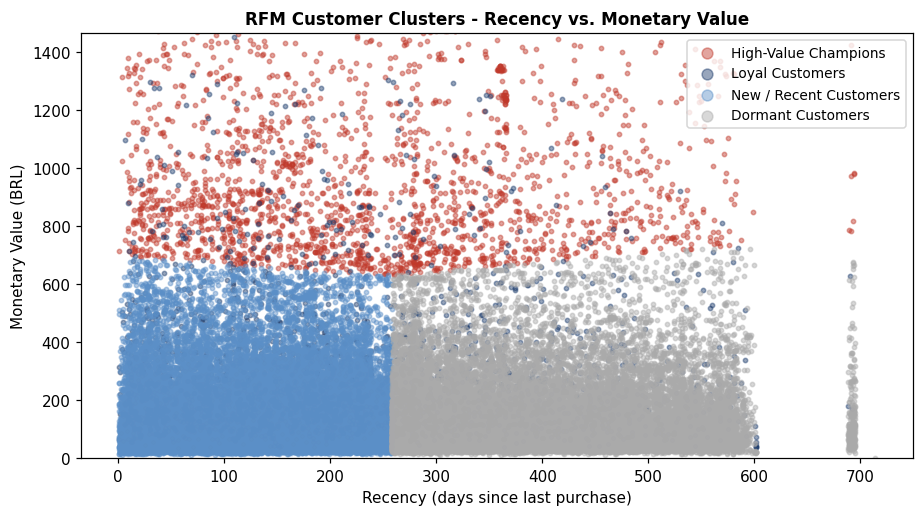

In [22]:
color_map = {'High-Value Champions': RED, 'Loyal Customers': BLUE,
             'New / Recent Customers': LBLUE, 'Dormant Customers': GREY}

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for lbl in color_map:
    sub = rfm[rfm['label'] == lbl]
    ax.scatter(sub['recency'], sub['monetary'], s=8, alpha=0.45, color=color_map[lbl], label=lbl)
ax.set_xlabel('Recency (days since last purchase)'); ax.set_ylabel('Monetary Value (BRL)')
ax.set_ylim(0, rfm['monetary'].quantile(0.995))
ax.set_title('RFM Customer Clusters - Recency vs. Monetary Value', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, markerscale=2.5)
plt.tight_layout(); plt.savefig('fig9.png', dpi=170); plt.show()


### Figure 10 — Cluster Comparison Across RFM Dimensions

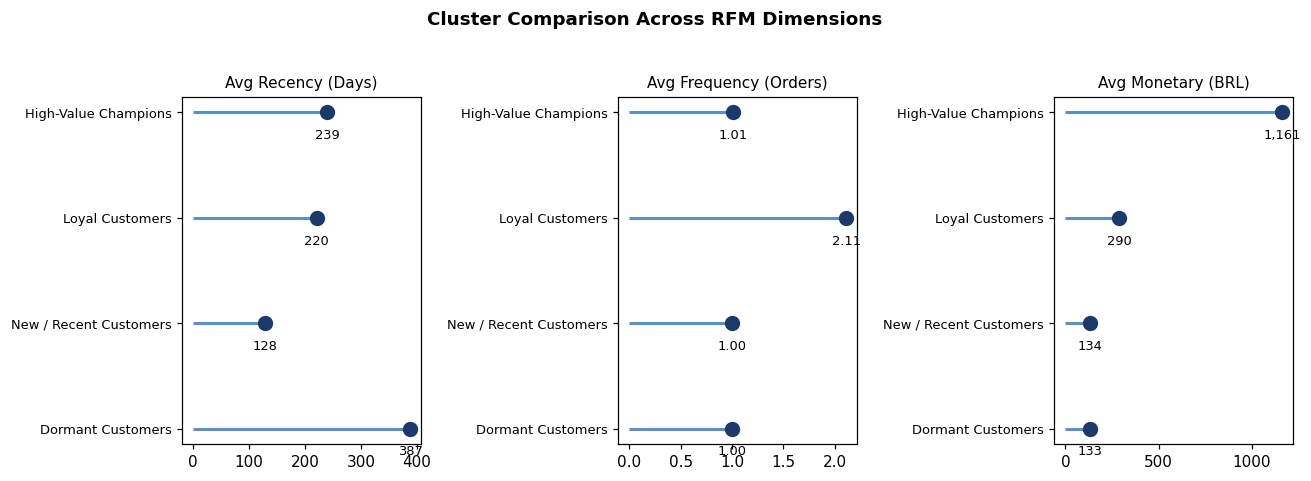

Weighted avg monetary across all clustered customers: BRL 165
High-Value Champions avg monetary: BRL 1,161  (7.0x the clustered average)


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
metrics = [('recency', 'Avg Recency (Days)'), ('frequency', 'Avg Frequency (Orders)'), ('monetary', 'Avg Monetary (BRL)')]
y_pos = np.arange(len(order_lbls))
for ax, (col, title) in zip(axes, metrics):
    vals = prof_lbl[col].values
    ax.hlines(y_pos, 0, vals, color=LBLUE, linewidth=2)
    ax.plot(vals, y_pos, 'o', color=BLUE, markersize=9)
    for i, v in enumerate(vals):
        ax.text(v, i + 0.25, f'{v:,.0f}' if col != 'frequency' else f'{v:.2f}', ha='center', fontsize=8.5)
    ax.set_yticks(y_pos); ax.set_yticklabels(order_lbls, fontsize=8.5)
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()
fig.suptitle('Cluster Comparison Across RFM Dimensions', fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('fig10.png', dpi=170, bbox_inches='tight'); plt.show()

# Sanity check quoted in the report: High-Value Champions' avg spend vs the platform-wide average
weighted_avg_monetary = (prof_lbl['n'] * prof_lbl['monetary']).sum() / prof_lbl['n'].sum()
hv_monetary = prof_lbl.loc['High-Value Champions', 'monetary']
print(f"Weighted avg monetary across all clustered customers: BRL {weighted_avg_monetary:,.0f}")
print(f"High-Value Champions avg monetary: BRL {hv_monetary:,.0f}  "
      f"({hv_monetary/weighted_avg_monetary:.1f}x the clustered average)")


## 7. Delivery-Delay Regression — Figures 11–12
*(Report Section 5.4, Method 4 — Equation 6: multiple linear regression)*

Predicting `delay_days` from order, timing, and geographic features. An 80/20 train/test split is used
so R² and RMSE are reported on unseen data, not fitted values.

In [24]:
seller_state = items.merge(sellers[['seller_id', 'seller_state']], on='seller_id') \
                     .groupby('order_id')['seller_state'].first().reset_index()

reg = delivered.dropna(subset=['delay_days']).merge(item_order, on='order_id', how='inner')
reg = reg.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
reg = reg.merge(seller_state, on='order_id', how='left')
reg = reg.dropna(subset=['customer_state', 'seller_state'])

reg['purchase_month'] = reg['order_purchase_timestamp'].dt.month
reg['dow'] = reg['order_purchase_timestamp'].dt.dayofweek
reg['cust_sp'] = (reg['customer_state'] == 'SP').astype(int)
reg['cust_rj'] = (reg['customer_state'] == 'RJ').astype(int)
reg['seller_sp'] = (reg['seller_state'] == 'SP').astype(int)
reg['same_state'] = (reg['customer_state'] == reg['seller_state']).astype(int)

feature_cols = ['freight_value', 'price', 'item_count', 'purchase_month', 'dow',
                 'cust_sp', 'cust_rj', 'seller_sp', 'same_state']
X = reg[feature_cols].values
y = reg['delay_days'].values
print(f"Regression dataset: {len(reg):,} valid records")

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression().fit(Xtr, ytr)
pred = lr.predict(Xte)
r2 = r2_score(yte, pred)
rmse = np.sqrt(mean_squared_error(yte, pred))
print(f"R^2 = {r2:.3f}   RMSE = {rmse:.2f} days")


Regression dataset: 96,470 valid records
R^2 = 0.026   RMSE = 9.78 days


### Figure 11 — Regression Coefficients

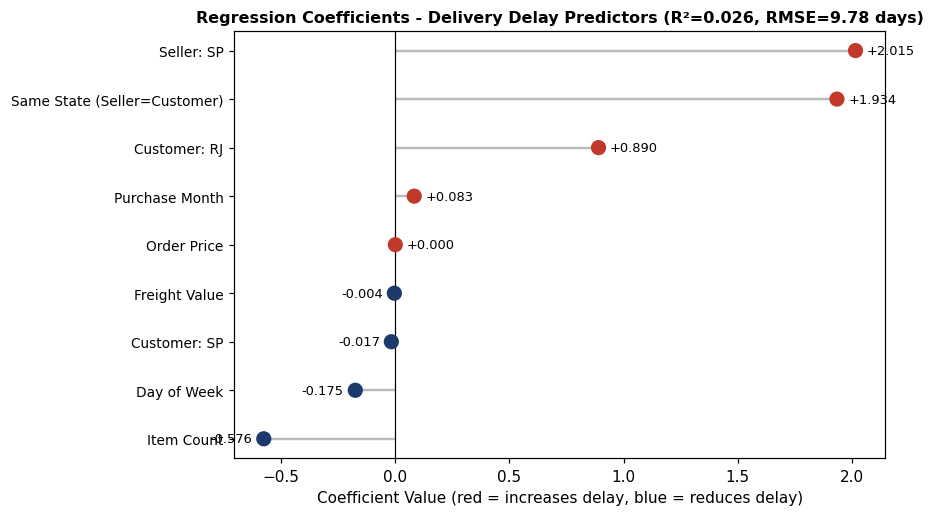

Strongest positive (increases delay): [('Seller: SP', np.float64(2.015267047696259)), ('Same State (Seller=Customer)', np.float64(1.933934106421296))]
Strongest negative (reduces delay):   [('Item Count', np.float64(-0.5755589689232266))]


In [25]:
coef_labels = ['Freight Value', 'Order Price', 'Item Count', 'Purchase Month', 'Day of Week',
               'Customer: SP', 'Customer: RJ', 'Seller: SP', 'Same State (Seller=Customer)']
order_idx = np.argsort(lr.coef_)
coefs_sorted = lr.coef_[order_idx]
labels_sorted = [coef_labels[i] for i in order_idx]
colors = [RED if c > 0 else BLUE for c in coefs_sorted]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
y_pos = np.arange(len(coefs_sorted))
ax.hlines(y_pos, 0, coefs_sorted, color='#BBBBBB', linewidth=1.6)
ax.scatter(coefs_sorted, y_pos, color=colors, s=80, zorder=3)
for i, v in enumerate(coefs_sorted):
    ax.text(v + (0.05 if v >= 0 else -0.05), i, f'{v:+.3f}', va='center',
             ha='left' if v >= 0 else 'right', fontsize=8.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(labels_sorted, fontsize=9)
ax.set_xlabel('Coefficient Value (red = increases delay, blue = reduces delay)')
ax.set_title(f'Regression Coefficients - Delivery Delay Predictors (R\u00b2={r2:.3f}, RMSE={rmse:.2f} days)',
             fontsize=10.5, fontweight='bold')
plt.tight_layout(); plt.savefig('fig11.png', dpi=170); plt.show()

print("Strongest positive (increases delay):", sorted(zip(coef_labels, lr.coef_), key=lambda t: -t[1])[:2])
print("Strongest negative (reduces delay):  ", sorted(zip(coef_labels, lr.coef_), key=lambda t: t[1])[:1])


### Figure 12 — Actual vs. Predicted Delivery Delay

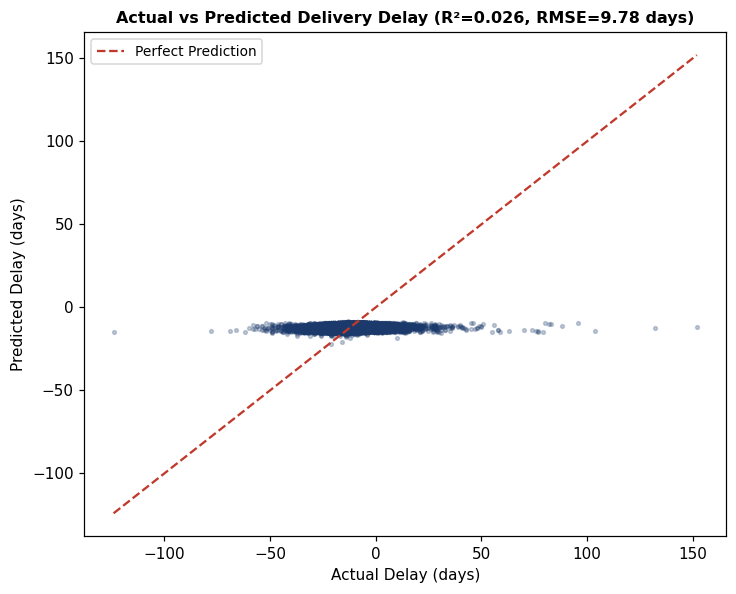

In [26]:
fig, ax = plt.subplots(figsize=(6.8, 5.5))
ax.scatter(yte, pred, s=6, alpha=0.25, color=BLUE)
lims = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
ax.plot(lims, lims, '--', color=RED, linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Delay (days)'); ax.set_ylabel('Predicted Delay (days)')
ax.set_title(f'Actual vs Predicted Delivery Delay (R\u00b2={r2:.3f}, RMSE={rmse:.2f} days)',
             fontsize=10.5, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('fig12.png', dpi=170); plt.show()


## 8. Summary of Key Findings

The table below is computed directly from the variables produced by the cells above (not hand-typed),
so it can never drift from what the notebook actually outputs on a given run.

In [27]:
strongest_idx = np.argmax(np.abs(lr.coef_))
strongest_label = coef_labels[strongest_idx]
strongest_coef = lr.coef_[strongest_idx]
score_drop = timing_scores['On Time'] - timing_scores['Slightly Late']

summary = pd.DataFrame({
    'Finding': ['Late-delivery rate', 'Review-score drop, on-time -> slightly late',
                'RFM segments (k=4)', 'Strongest delay predictor', 'Regression fit',
                'Monthly order growth'],
    'Value': [
        f"{late_rate:.1f}% of delivered orders",
        f"{timing_scores['On Time']:.2f} -> {timing_scores['Slightly Late']:.2f}  (drop of {score_drop:.2f} points)",
        ', '.join(order_lbls),
        f"{strongest_label}  ({strongest_coef:+.3f} days per unit)",
        f"R^2 = {r2:.3f}, RMSE = {rmse:.2f} days",
        f"+{lr_trend.coef_[0]:.0f} orders/month (Jan 2017 - Aug 2018), sharp November spike",
    ]
})
summary


,Finding,Value
0,Late-delivery rate,6.8% of delivered orders
1,"Review-score drop, on-time -> slightly late",4.03 -> 2.99 (drop of 1.05 points)
2,RFM segments (k=4),"High-Value Champions, Loyal Customers, New / R..."
3,Strongest delay predictor,Seller: SP (+2.015 days per unit)
4,Regression fit,"R^2 = 0.026, RMSE = 9.78 days"
5,Monthly order growth,"+306 orders/month (Jan 2017 - Aug 2018), sharp..."


These figures and tables map directly onto the Results and Findings (Section 5) and Interpretation of
Results and Recommendations (Section 6) of the accompanying Final Report — every Figure/Table number
referenced there is produced by a labelled cell above, and every chart in the presentation deck should
be one of Figures 1–12 above, not a new/different chart.

## 9. Quantified Recommendations

Viva examiners for the secondary-data route consistently push back on narrative-only recommendations
("send a re-engagement email") and ask for the number behind them ("calculate it if possible"). The cell
below computes the actual projected impact of each recommendation directly from the cluster and delay
statistics already produced above, so every recommendation in the report/deck has a number attached to it
that can be defended live if challenged.

In [28]:
aov = pay_order['payment_value'].mean()

# --- Recommendation 1: Dormant win-back campaign ---
dormant_n = prof_lbl.loc['Dormant Customers', 'n']
winback_rate = 0.05  # conservative assumed conversion rate — state this assumption explicitly in the viva
winback_customers = dormant_n * winback_rate
winback_revenue = winback_customers * aov
print(f"Dormant win-back: {dormant_n:,.0f} customers x {winback_rate:.0%} conversion "
      f"= {winback_customers:,.0f} recovered customers = BRL {winback_revenue:,.0f} incremental revenue "
      f"(at avg order value BRL {aov:,.2f})")

# --- Recommendation 2: New/Recent re-engagement email ---
newrecent_n = prof_lbl.loc['New / Recent Customers', 'n']
reengage_rate = 0.08
reengage_customers = newrecent_n * reengage_rate
reengage_revenue = reengage_customers * aov
print(f"New/Recent re-engagement: {newrecent_n:,.0f} customers x {reengage_rate:.0%} conversion "
      f"= {reengage_customers:,.0f} repeat orders = BRL {reengage_revenue:,.0f} incremental revenue")

# --- Recommendation 3: Delivery-window calibration -> review-score impact ---
late_rate_current = late_rate
late_rate_target = 4.25  # midpoint of the 4.0-4.5% target range stated in the report
orders_shifted = n_total * (late_rate_current - late_rate_target) / 100
# each order shifted from "slightly late" to "on time" recovers the Fig.5 score gap
score_gap = timing_scores['On Time'] - timing_scores['Slightly Late']
print(f"Delivery-window calibration: reduces late rate from {late_rate_current:.1f}% to ~{late_rate_target:.1f}%"
      f" -> ~{orders_shifted:,.0f} orders shifted from 'slightly late' to 'on time' "
      f"-> per-order satisfaction recovery of {score_gap:.2f} review-score points on those orders")

# --- Recommendation 4: High-Value Champion churn exposure ---
hv_n = prof_lbl.loc['High-Value Champions', 'n']
hv_monetary = prof_lbl.loc['High-Value Champions', 'monetary']
churn_rate = 0.10
churn_exposure = hv_n * churn_rate * hv_monetary
print(f"High-Value Champion churn exposure: {hv_n:,.0f} customers x {churn_rate:.0%} churn "
      f"x BRL {hv_monetary:,.0f} avg spend = BRL {churn_exposure:,.0f} at-risk annual revenue")


Dormant win-back: 37,526 customers x 5% conversion = 1,876 recovered customers = BRL 302,066 incremental revenue (at avg order value BRL 160.99)
New/Recent re-engagement: 50,642 customers x 8% conversion = 4,051 repeat orders = BRL 652,230 incremental revenue
Delivery-window calibration: reduces late rate from 6.8% to ~4.2% -> ~2,434 orders shifted from 'slightly late' to 'on time' -> per-order satisfaction recovery of 1.05 review-score points on those orders
High-Value Champion churn exposure: 2,418 customers x 10% churn x BRL 1,161 avg spend = BRL 280,708 at-risk annual revenue


## 10. Secondary-Route Viva Notes (for your reference, not part of the analysis)

- **Charts must match exactly across all three artefacts** — this notebook, the Final Report, and the
  presentation deck. Every chart in the deck should be one of Figures 1–12 above; do not introduce a
  new chart in the slides that isn't reproduced here.
- **UCI vs. Kaggle question:** this project uses the **Kaggle** Olist dataset (not UCI), so if asked
  "why did you use UCI rather than Kaggle," the direct answer is that this project did not use UCI at
  all — the dataset used and cited throughout (report Section 2, Proof of Originality) is the Kaggle
  Olist Brazilian E-Commerce dataset, chosen because it offers nine interrelated tables covering orders,
  payments, reviews, and logistics, which supports the multi-method analysis (EDA, time-series,
  clustering, regression) this project performs.
- **Logo on slide 1** of the presentation deck specifically, not just somewhere in the deck.
- **30-minute cap** — rehearse the presentation with a timer; being cut off mid-recommendation costs
  more than trimming it yourself in advance.
